In [94]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [96]:
iris=load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target

In [98]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [100]:
df = df[df['target']!= 0][['sepal length (cm)','sepal width (cm)','target']]

In [102]:
df.head()

,sepal length (cm),sepal width (cm),target
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

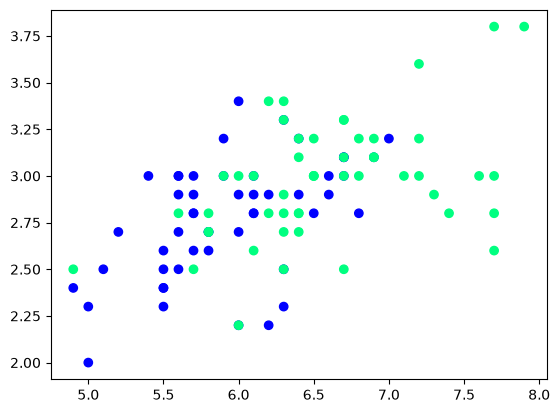

In [106]:
plt.scatter(df['sepal length (cm)'],df['sepal width (cm)'],c=df['target'],cmap='winter')

In [108]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [110]:
df_train

,sepal length (cm),sepal width (cm),target
128,6.4,2.8,2
123,6.3,2.7,2
77,6.7,3.0,1
80,5.5,2.4,1
71,6.1,2.8,1
92,5.8,2.6,1
115,6.4,3.2,2
91,6.1,3.0,1
131,7.9,3.8,2
74,6.4,2.9,1


In [112]:
df_val

,sepal length (cm),sepal width (cm),target
68,6.2,2.2,1
95,5.7,3.0,1
52,6.9,3.1,1
130,7.4,2.8,2
126,6.2,2.8,2


In [114]:
df_test

,sepal length (cm),sepal width (cm),target
72,6.3,2.5,1
100,6.3,3.3,2
98,5.1,2.5,1
122,7.7,2.8,2
107,7.3,2.9,2


In [116]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

# case-1 Bagging

In [165]:
df_bag = df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal length (cm),sepal width (cm),target
131,7.9,3.8,2
115,6.4,3.2,2
74,6.4,2.9,1
74,6.4,2.9,1
128,6.4,2.8,2
91,6.1,3.0,1
115,6.4,3.2,2
80,5.5,2.4,1


In [163]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score


In [167]:
dt_bag1 = DecisionTreeClassifier()

In [203]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

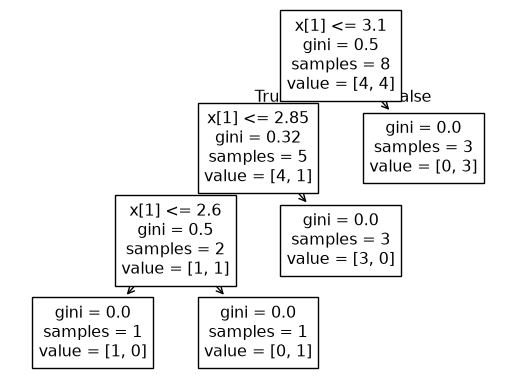

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


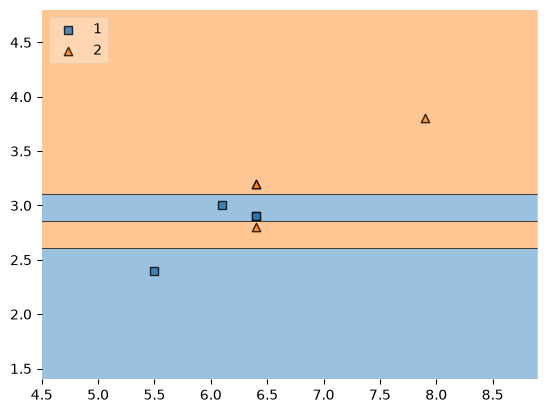

In [171]:
evaluate(dt_bag1,X,y)

In [217]:
df_bag = df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal length (cm),sepal width (cm),target
91,6.1,3.0,1
131,7.9,3.8,2
71,6.1,2.8,1
123,6.3,2.7,2
80,5.5,2.4,1
92,5.8,2.6,1
91,6.1,3.0,1
92,5.8,2.6,1


In [219]:
dt_bag2= DecisionTreeClassifier()



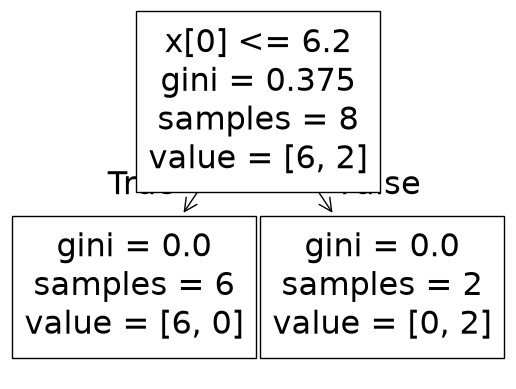

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


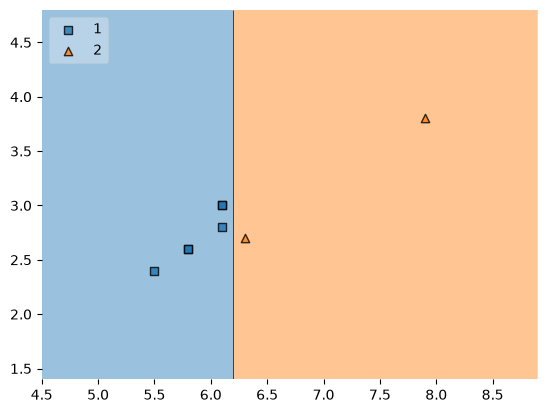

In [221]:
evaluate(dt_bag2,X,y)

In [223]:
df_bag =df_train.sample(5,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal length (cm),sepal width (cm),target
115,6.4,3.2,2
80,5.5,2.4,1
91,6.1,3.0,1
92,5.8,2.6,1
128,6.4,2.8,2


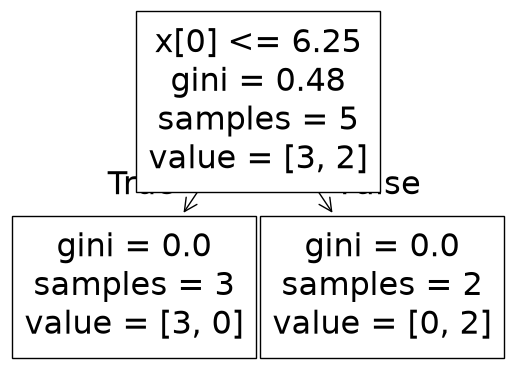

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


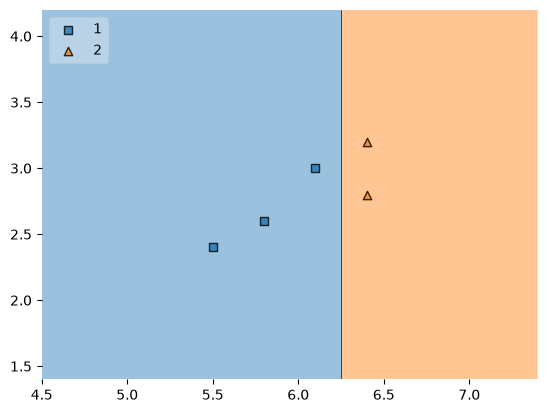

In [225]:
dt_bag3 =  DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predicts

In [252]:
df_test

,sepal length (cm),sepal width (cm),target
96,5.7,2.9,1
98,5.1,2.5,1
84,5.4,3.0,1
122,7.7,2.8,2
139,6.9,3.1,2


In [254]:
print('Predict 1:',dt_bag1.predict(np.array([5.1,2.5]).reshape(1,2)))
print('Predict 1:',dt_bag2.predict(np.array([5.1,2.5]).reshape(1,2)))
print('Predict 1:',dt_bag3.predict(np.array([5.1,2.5]).reshape(1,2)))

Predict 1: [1]
Predict 1: [1]
Predict 1: [1]


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [256]:
print('Predict 1:',dt_bag1.predict(np.array([2.1,5.0]).reshape(1,2)))
print('Predict 1:',dt_bag2.predict(np.array([2.1,5.0]).reshape(1,2)))
print('Predict 1:',dt_bag3.predict(np.array([2.1,5.0]).reshape(1,2)))

Predict 1: [2]
Predict 1: [1]
Predict 1: [1]


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## pasting - row sampling without replacement

In [259]:
df_train.sample(5) #pasting do row sampling without replacement

,sepal length (cm),sepal width (cm),target
71,6.1,2.8,1
91,6.1,3.0,1
131,7.9,3.8,2
74,6.4,2.9,1
80,5.5,2.4,1


## random subspaces - column sampling

In [266]:
iris=load_iris()
df1 = pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target

In [268]:
df1.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,4.4,2.9,1.4,0.2
81,5.5,2.4,3.7,1.0
5,5.4,3.9,1.7,0.4
97,6.2,2.9,4.3,1.3
123,6.3,2.7,4.9,1.8
100,6.3,3.3,6.0,2.5
42,4.4,3.2,1.3,0.2
0,5.1,3.5,1.4,0.2
105,7.6,3.0,6.6,2.1
120,6.9,3.2,5.7,2.3


In [270]:
df1.sample(2,replace=True,axis=1)

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2
...,...,...
145,6.7,2.3
146,6.3,1.9
147,6.5,2.0
148,6.2,2.3


## Random patches - column and row sampling

In [278]:
df1.sample(7,replace=True).sample(2,replace=True,axis=1)

,sepal length (cm),petal width (cm)
119,6.0,1.5
91,6.1,1.4
139,6.9,2.1
144,6.7,2.5
37,4.9,0.1
118,7.7,2.3
12,4.8,0.1
